# Laboratorio - Péndulo Simple utilizando Phyphox

Análisis de datos experimentales obtenidos mediante el sensor giroscópico de un dispositivo móvil.

Autores:
-  Mariana Alexandra
- Ediem Andrey
- Miguel Plazas


In [3]:
import pandas as pd   # Leer archivo Excel
import matplotlib.pyplot as plt  # Graficas
import numpy as np  # Calculos

Verificar lectura archivo


In [4]:
archivo = "Pndulo 2026-07-27 12-50-50.xls"

excel = pd.ExcelFile(archivo)

print(excel.sheet_names)

['Raw Data', 'Autocorrelation', 'Resonance', 'Metadata Device', 'Metadata Time']


RAW DATA

In [31]:
datos = pd.read_excel(archivo,sheet_name="Raw Data")

pRIMEROS 5 DATO S

In [6]:
datos.head()

,Time (s),Rotation x (rad/s),Rotation y (rad/s),Rotation z (rad/s)
0,0.044678,0.107818,0.021838,0.000916
1,0.065331,0.044899,-0.012675,0.072540
2,0.085984,0.009621,0.011606,0.098502
3,0.106637,0.005192,0.050549,0.081398
4,0.127290,0.012828,0.007789,0.016035


Tamaño de datos( cantidad)

In [7]:
datos.shape

(484, 4)

Verificar si existen datos faltantes

In [8]:
datos.isnull().sum()

,0
Time (s),0
Rotation x (rad/s),0
Rotation y (rad/s),0
Rotation z (rad/s),0


In [9]:
datos.describe()

,Time (s),Rotation x (rad/s),Rotation y (rad/s),Rotation z (rad/s)
count,484.000000,484.000000,484.000000,484.000000
mean,5.032358,-0.018200,0.009543,-0.100039
std,2.888569,0.073535,0.409490,2.022052
min,0.044678,-0.206167,-0.973718,-6.205928
25%,2.538529,-0.068722,-0.374460,-1.781396
50%,5.032366,-0.026573,0.011759,-0.182954
75%,7.526190,0.030391,0.385379,1.724929
max,10.020004,0.242055,1.455843,4.469239


Variables

In [10]:
print(datos.columns)

Index(['Time (s)', 'Rotation x (rad/s)', 'Rotation y (rad/s)',
       'Rotation z (rad/s)'],
      dtype='object')


In [11]:
tiempo = datos['Time (s)']
rot_x = datos['Rotation x (rad/s)']
rot_y = datos['Rotation y (rad/s)']
rot_z = datos['Rotation z (rad/s)']

Grafica Velocidad Angular (Eje X)

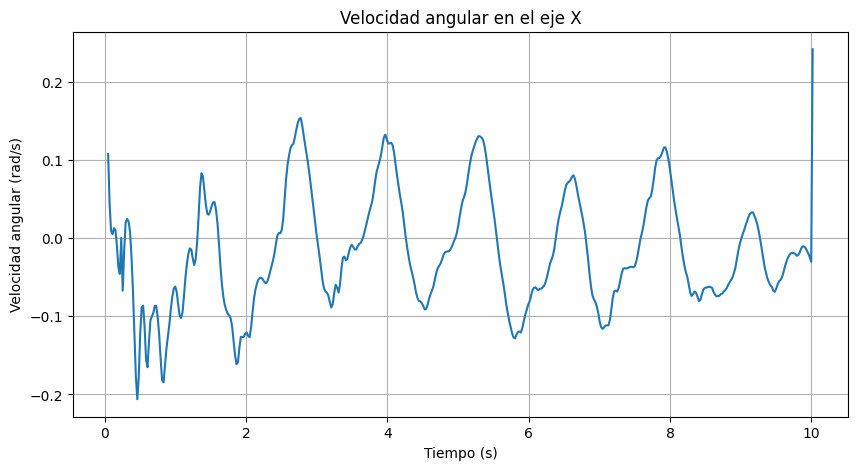

In [14]:
plt.figure(figsize=(10,5))

plt.plot(tiempo, rot_x)

plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad angular (rad/s)")
plt.title("Velocidad angular en el eje X")

plt.grid()

plt.show()

Grafica Velocidad Angular (Eje Y)

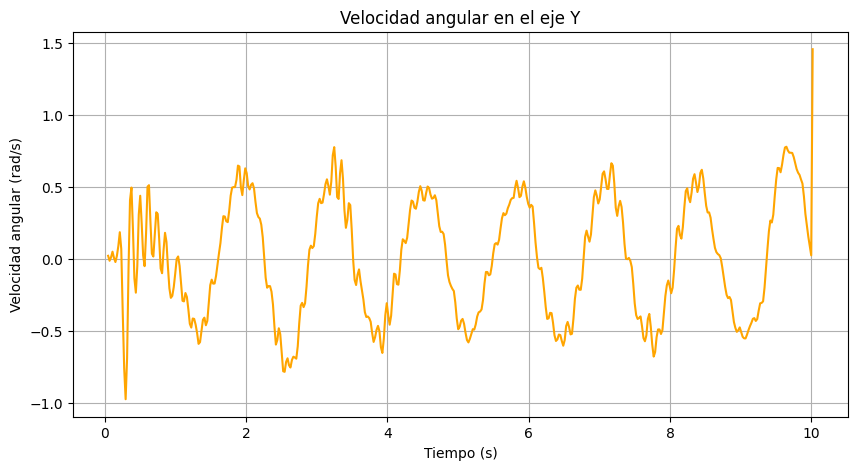

In [15]:
plt.figure(figsize=(10,5))

plt.plot(tiempo, rot_y,color='orange')

plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad angular (rad/s)")
plt.title("Velocidad angular en el eje Y")

plt.grid()

plt.show()

Grafica Velocidad Angular (Eje Z)

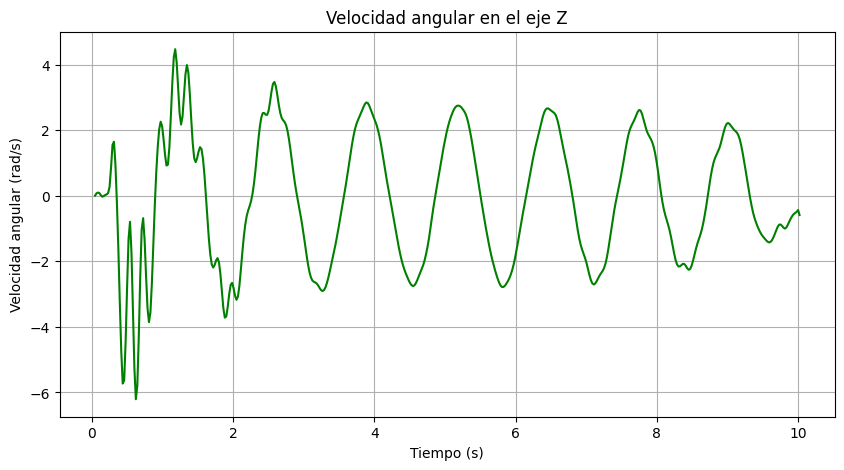

In [16]:
plt.figure(figsize=(10,5))

plt.plot(tiempo, rot_z,color='green')

plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad angular (rad/s)")
plt.title("Velocidad angular en el eje Z")

plt.grid()

plt.show()

Comparación de las velocidades angulares


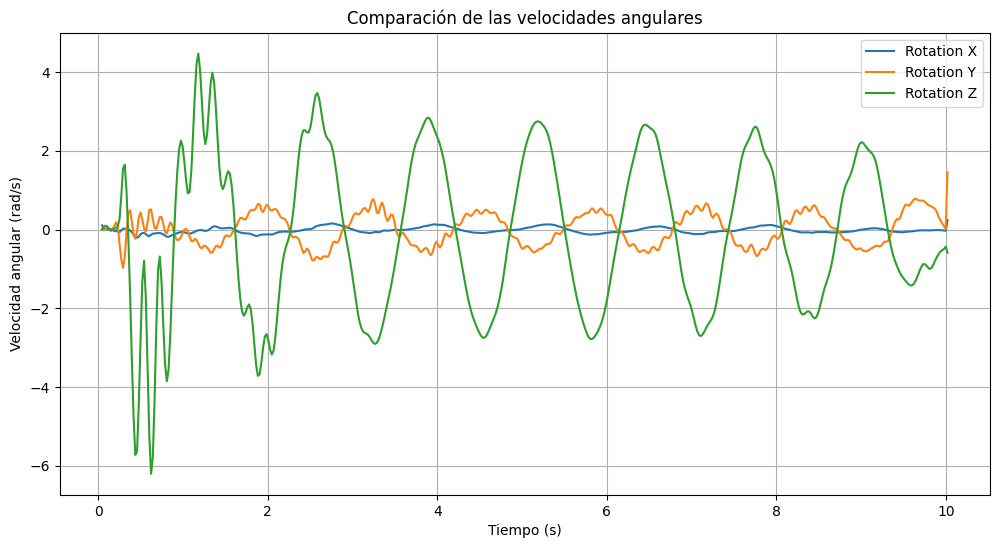

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(tiempo, rot_x, label="Rotation X")
plt.plot(tiempo, rot_y, label="Rotation Y")
plt.plot(tiempo, rot_z, label="Rotation Z")

plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad angular (rad/s)")
plt.title("Comparación de las velocidades angulares")

plt.legend()
plt.grid()

plt.show()

Grafica Autocorrelation

In [17]:
auto = pd.read_excel(archivo, sheet_name="Autocorrelation")

print(auto.columns)

auto.head()

Index(['Time shift (s)', 'Autocorrelation of sum'], dtype='object')


,Time shift (s),Autocorrelation of sum
0,0.000000,3.030938
1,0.020653,2.965395
2,0.041306,2.791906
3,0.061959,2.567107
4,0.082612,2.357491


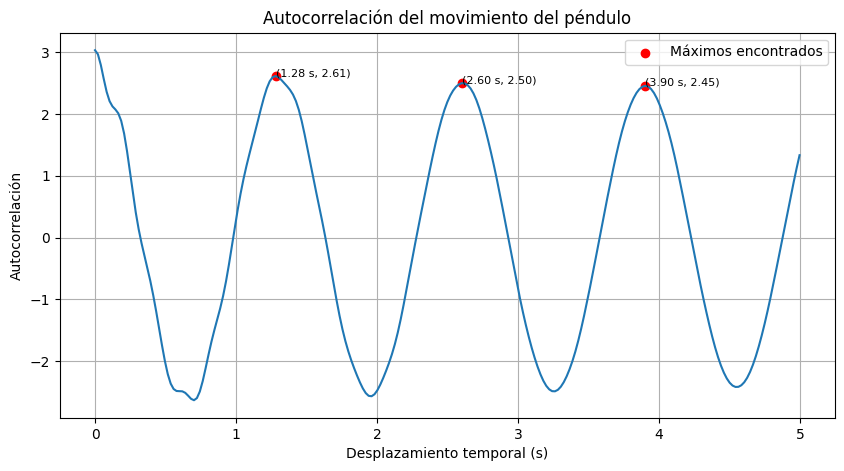

Períodos encontrados:
[1.32179047 1.30113328]

Período promedio = 1.3115 s
Longitud experimental = 0.4274 m
Error porcentual = 3.73 %


In [40]:

# Leer la hoja Autocorrelation
auto = pd.read_excel(archivo, sheet_name="Autocorrelation")

# Crear las variables
time_shift = auto["Time shift (s)"]
autocorrelation = auto["Autocorrelation of sum"]

# Buscar los máximos de la autocorrelación
maximos, _ = find_peaks(autocorrelation)

# Graficar
plt.figure(figsize=(10,5))

# Curva de autocorrelación
plt.plot(time_shift, autocorrelation)

# Graficar los máximos encontrados
plt.scatter(time_shift[maximos],autocorrelation[maximos],color='red',label='Máximos encontrados')

# Mostrar las coordenadas de cada máximo
for i in maximos:
    plt.text(time_shift[i],autocorrelation[i], f"({time_shift[i]:.2f} s, {autocorrelation[i]:.2f})",fontsize=8)

# Configuración de la gráfica
plt.xlabel("Desplazamiento temporal (s)")
plt.ylabel("Autocorrelación")
plt.title("Autocorrelación del movimiento del péndulo")

plt.grid(True)
plt.legend()

plt.show()

# Calculos
# Períodos entre máximos
tiempo_maximos = time_shift[maximos]
periodos = np.diff(tiempo_maximos)

print("Períodos encontrados:")
print(periodos)


periodo_promedio = np.mean(periodos)

print(f"\nPeríodo promedio = {periodo_promedio:.4f} s")

# Longitud_experimental

g = 9.81

longitud_experimental = (g*periodo_promedio**2)/(4*np.pi**2)

print(f"Longitud experimental = {longitud_experimental:.4f} m")

# Longitud real

longitud_real = 0.412

# Error porcentual

error_porcentual = abs(longitud_experimental - longitud_real)/longitud_real*100

print(f"Error porcentual = {error_porcentual:.2f} %")



Grafica Resonancia

In [21]:
res = pd.read_excel(archivo, sheet_name="Resonance")
print(res.columns)
res.head()

Index(['Frequency (Hz)', 'Rel. amplitude (a.u.)'], dtype='object')


,Frequency (Hz),Rel. amplitude (a.u.)
0,0.756549,0.994779
1,0.756549,0.994779
2,0.756549,0.994779
3,0.756549,0.995915
4,0.756549,0.996936


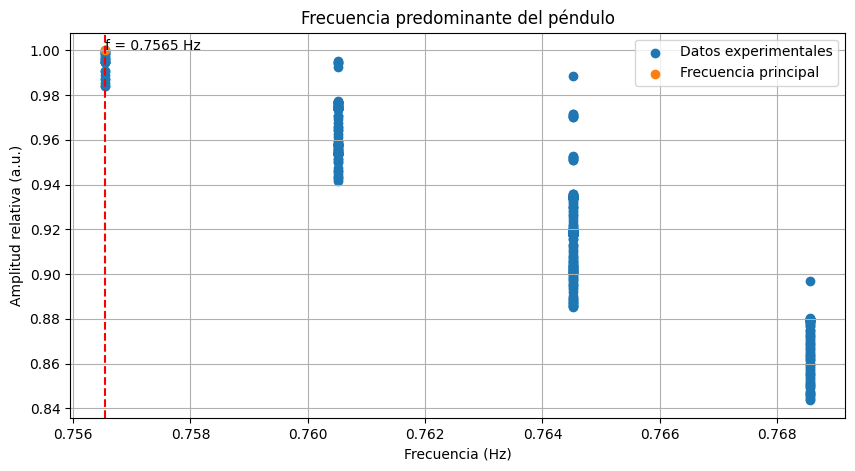

In [37]:

# Leer la hoja Resonance
res = pd.read_excel(archivo, sheet_name="Resonance")

# Crear las variables
frecuencia = res["Frequency (Hz)"]
amplitud = res["Rel. amplitude (a.u.)"]

# Encontrar la frecuencia predominante
indice_max = amplitud.idxmax()

frecuencia_principal = frecuencia[indice_max]
amplitud_maxima = amplitud[indice_max]

# Graficar
plt.figure(figsize=(10,5))

# Datos experimentales
plt.scatter(frecuencia, amplitud,label="Datos experimentales")

# Frecuencia predominante
plt.scatter(frecuencia_principal, amplitud_maxima,label="Frecuencia principal")

# Línea vertical en la frecuencia predominante
plt.axvline(x=frecuencia_principal, linestyle="--",color="red")

# Mostrar el valor de la frecuencia predominante
plt.text(frecuencia_principal,amplitud_maxima, f"f = {frecuencia_principal:.4f} Hz", fontsize=10)

# Etiquetas y título
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud relativa (a.u.)")
plt.title("Frecuencia predominante del péndulo")

# Cuadrícula y leyenda
plt.grid(True)
plt.legend()

plt.show()

In [38]:

# Calculos
# Período experimental

periodo = 1 / frecuencia_principal

print(f"Período experimental = {periodo:.4f} s")

# Longitud_experimental
g = 9.81

longitud_experimental = (g * periodo**2)/(4*np.pi**2)

print(f"Longitud experimental = {longitud_experimental:.4f} m")

# Longitud real

longitud_real = 0.412

# Error porcentual

error_porcentual = (abs(longitud_experimental - longitud_real)/ longitud_real)*100

print(f"Error porcentual = {error_porcentual:.2f} %")

Período experimental = 1.3218 s
Longitud experimental = 0.4341 m
Error porcentual = 5.37 %
